# Test Mask Generation for FlappyBird

This notebook tests color-based segmentation to create semantic masks:
- Bird pixels = -1
- Background pixels = 0  
- Pipe pixels = +1

We capture frames over 200 steps (every 10 steps) to ensure we see pipes in the visualization.


In [ ]:
import flappy_bird_env  # noqa
import numpy as np
import matplotlib.pyplot as plt
import cv2
import gymnasium as gym

print("✓ Libraries imported successfully")


✓ Libraries imported successfully


## Mask Generation Function

Create a function that converts RGB images to semantic masks using HSV color space segmentation.


In [ ]:
def create_mask(observation, crop_bottom=100, resize_factor=1.0, final_size=None):
    """
    Create a semantic mask from RGB observation.
    
    Bird pixels = -1, Background pixels = 0, Pipe pixels = +1
    
    Args:
        observation: RGB image array of shape (H, W, 3) with values 0-255
        crop_bottom: Number of pixels to crop from bottom (default: 100)
        resize_factor: Factor to resize the image (default: 1.0 = no resize)
                      Uses nearest neighbor interpolation to preserve discrete values
        final_size: Final size to stretch to (e.g., 21 for 21x21). If None, no stretching.
                   Uses nearest neighbor interpolation to preserve discrete values
        
    Returns:
        Mask array with values -1, 0, or +1 (shape depends on crop, resize, and final_size)
    """
    # Crop bottom pixels to remove ground
    h, w = observation.shape[:2]
    cropped_obs = observation[:h-crop_bottom, :]  # Remove bottom rows
    
    # Resize if needed (using nearest neighbor to preserve discrete values)
    if resize_factor != 1.0:
        new_h = int(cropped_obs.shape[0] * resize_factor)
        new_w = int(cropped_obs.shape[1] * resize_factor)
        # Use INTER_NEAREST to preserve discrete pixel values
        cropped_obs = cv2.resize(cropped_obs.astype(np.uint8), (new_w, new_h), 
                                 interpolation=cv2.INTER_NEAREST)
    
    # Stretch to final size if specified (using nearest neighbor to preserve discrete values)
    if final_size is not None:
        cropped_obs = cv2.resize(cropped_obs.astype(np.uint8), (final_size, final_size), 
                                 interpolation=cv2.INTER_NEAREST)
    
    # Convert RGB to HSV for better color segmentation
    hsv = cv2.cvtColor(cropped_obs.astype(np.uint8), cv2.COLOR_RGB2HSV)
    
    # Initialize mask as background (0)
    mask = np.zeros((cropped_obs.shape[0], cropped_obs.shape[1]), dtype=np.float32)
    
    # Identify bird pixels (using global threshold configuration)
    bird_lower = np.array([BIRD_H_MIN, BIRD_S_MIN, BIRD_V_MIN])
    bird_upper = np.array([BIRD_H_MAX, BIRD_S_MAX, BIRD_V_MAX])
    bird_mask = cv2.inRange(hsv, bird_lower, bird_upper)
    
    # Also detect white pixels (low saturation, high value) for bird's eye/white features
    # White in HSV: S < 30, V > 200 (approximately)
    white_mask = cv2.inRange(hsv, np.array([0, 0, 200]), np.array([180, 30, 255]))
    
    # Combine bird color mask and white mask
    bird_mask = cv2.bitwise_or(bird_mask, white_mask)
    mask[bird_mask > 0] = -1.0
    
    # Identify pipe pixels (using global threshold configuration)
    pipe_lower = np.array([PIPE_H_MIN, PIPE_S_MIN, PIPE_V_MIN])
    pipe_upper = np.array([PIPE_H_MAX, PIPE_S_MAX, PIPE_V_MAX])
    pipe_mask = cv2.inRange(hsv, pipe_lower, pipe_upper)
    mask[pipe_mask > 0] = 1.0
    
    # Background is already 0 (default)
    
    return mask

print("✓ Mask generation function created")


✓ Mask generation function created


## Capture Frames from FlappyBird

Use the same strategy as `flappy_bird_demo.ipynb`: run for 200 steps and capture every 10 steps to ensure we see pipes.


In [ ]:
# Create environment and capture frames over 200 steps
env = gym.make("FlappyBird-v0", render_mode="rgb_array")
observation, _ = env.reset()
observation = np.asarray(observation, dtype=np.uint8)

# Store frames at different steps to see pipes
# Capture frames every 10 steps to see progression, including later steps when pipes appear
frames_to_capture = list(range(0, 400, 10))  # Capture every 10 steps: 0, 10, 20, 30, ..., 190
captured_frames = []

# Run more steps to see pipes appear (pipes typically appear after ~50-100 steps)
for step in range(400):  # Run 200 steps
    # Store frame if we want to capture it
    if step in frames_to_capture:
        captured_frames.append({
            'step': step,
            'rgb': observation.copy().astype(np.uint8)
        })
    
    # Flap every 10 steps (action 1 = flap, action 0 = no flap)
    action = 1 if step % 10 == 0 else 0  # Flaps at steps 0, 10, 20, ...
    observation, reward, terminated, truncated, _ = env.step(action)
    observation = np.asarray(observation, dtype=np.uint8)
    
    if terminated or truncated:
        observation, _ = env.reset()
        observation = np.asarray(observation, dtype=np.uint8)

env.close()

print(f"✓ Captured {len(captured_frames)} frames")
print(f"Frame shape: {captured_frames[0]['rgb'].shape}")
print(f"Captured at steps: {[f['step'] for f in captured_frames]}")


✓ Captured 40 frames
Frame shape: (800, 576, 3)
Captured at steps: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390]


## Generate Masks

Apply mask generation to all captured frames and compute statistics.


In [ ]:
# Generate masks for all frames (using default crop_bottom=100, resize_factor=1.0)
for frame_data in captured_frames:
    frame_data['mask'] = create_mask(frame_data['rgb'], crop_bottom=100, resize_factor=1.0)
    frame_data['stats'] = {
        'bird_pixels': np.sum(frame_data['mask'] == -1),
        'background_pixels': np.sum(frame_data['mask'] == 0),
        'pipe_pixels': np.sum(frame_data['mask'] == 1),
        'total_pixels': frame_data['mask'].size
    }

print("✓ Masks generated for all frames")
print(f"\nSample statistics (step {captured_frames[0]['step']}):")
stats = captured_frames[0]['stats']
print(f"  Bird pixels: {stats['bird_pixels']:,} ({stats['bird_pixels']/stats['total_pixels']*100:.2f}%)")
print(f"  Background pixels: {stats['background_pixels']:,} ({stats['background_pixels']/stats['total_pixels']*100:.2f}%)")
print(f"  Pipe pixels: {stats['pipe_pixels']:,} ({stats['pipe_pixels']/stats['total_pixels']*100:.2f}%)")


NameError: name 'BIRD_H_MIN' is not defined

## Interactive Crop Testing

Test different bottom crop values to find the optimal region to cut out.


Testing crop value: 100 pixels (Step 190)


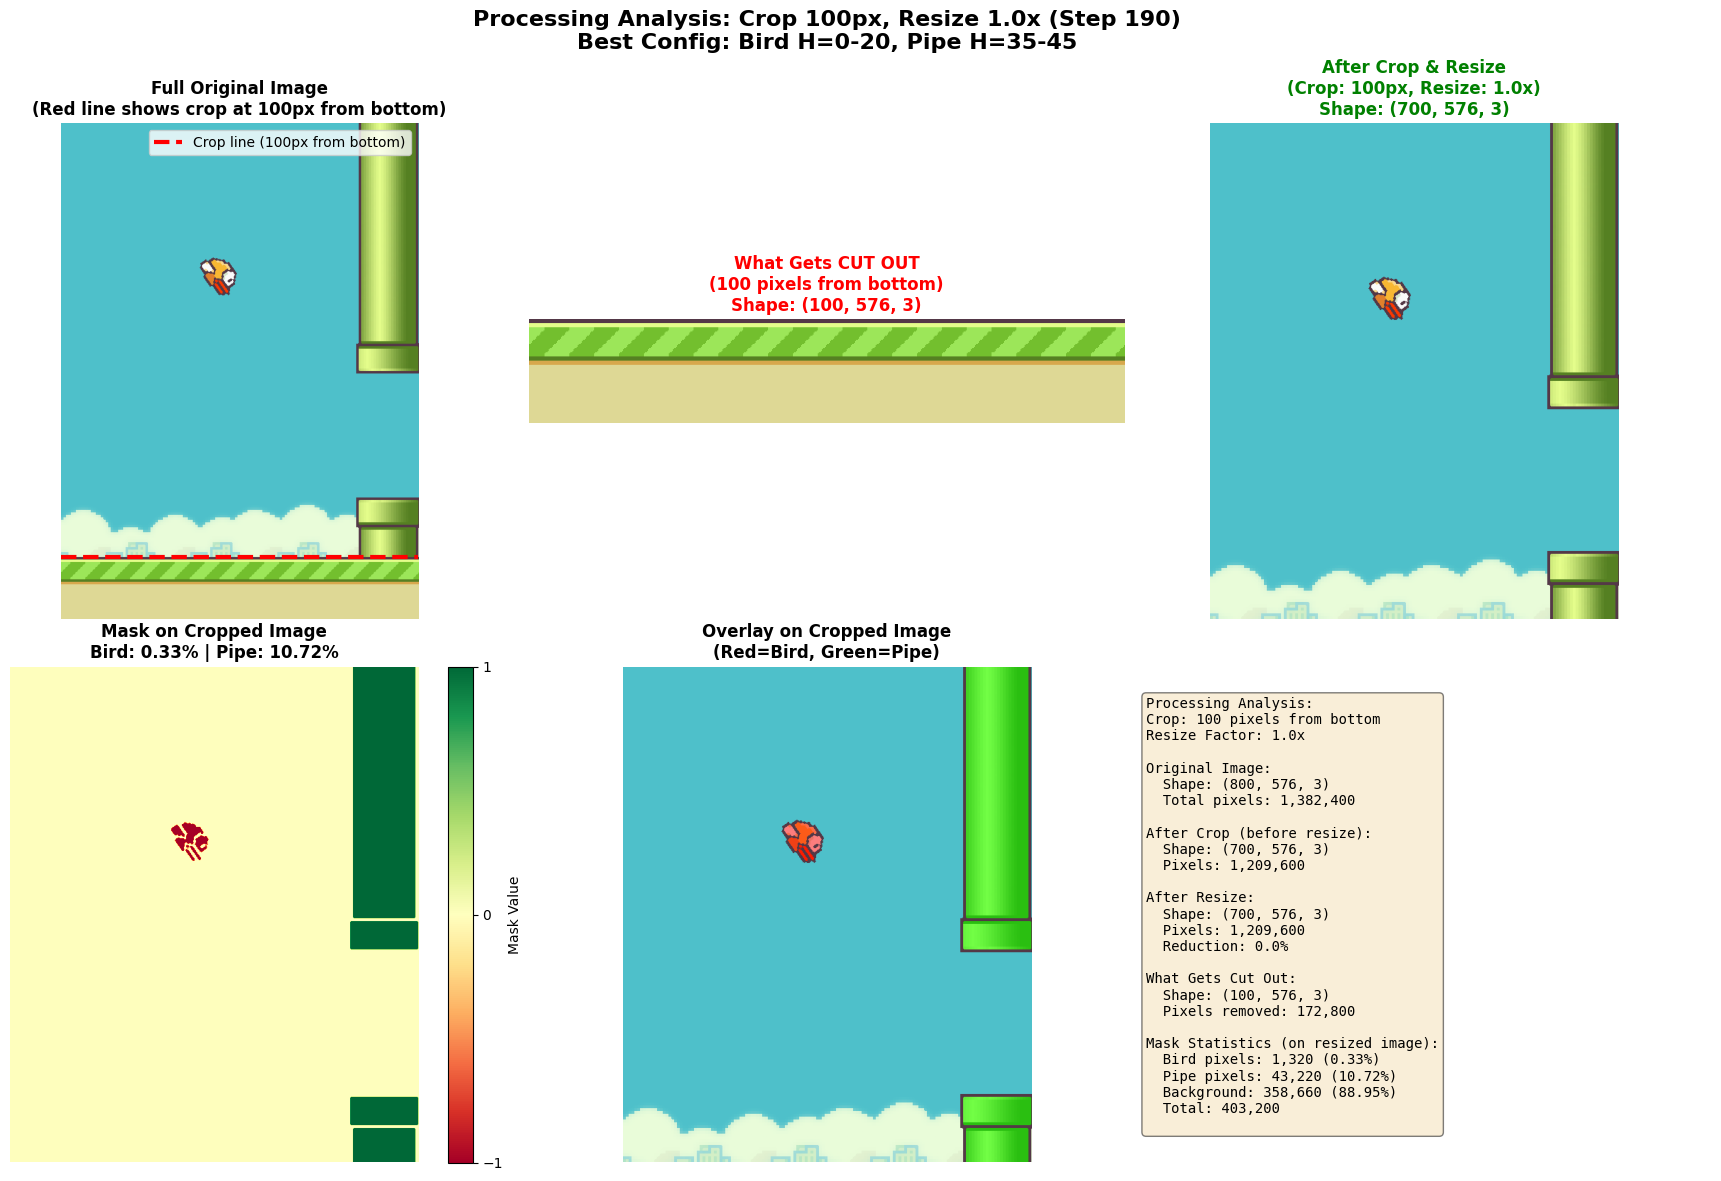


Adjust RESIZE_FACTOR above (currently 1.0) and re-run to test different resize values!


In [ ]:
# INTERACTIVE: Adjust CROP_BOTTOM and RESIZE_FACTOR to test different values
CROP_BOTTOM = 100  # Pixels to crop from bottom (fixed at 100 based on testing)
RESIZE_FACTOR = 1.0  # Resize factor (1.0 = no resize, 0.5 = half size, 2.0 = double size)

# Get the frame at step 190
test_frame = None
for frame in captured_frames:
    if frame['step'] == 190:
        test_frame = frame['rgb']
        break

if test_frame is None:
    test_frame = captured_frames[-1]['rgb']
    print(f"Warning: Step 190 not found, using step {captured_frames[-1]['step']} instead")
else:
    print(f"Testing crop value: {CROP_BOTTOM} pixels (Step 190)")

# Extract what gets cropped out and what remains
h, w = test_frame.shape[:2]
cropped_rgb = test_frame[:h-CROP_BOTTOM, :]  # What we keep (before resize)
cropped_out = test_frame[h-CROP_BOTTOM:, :]  # What gets cut out

# Apply resize to the cropped image (for display)
if RESIZE_FACTOR != 1.0:
    new_h = int(cropped_rgb.shape[0] * RESIZE_FACTOR)
    new_w = int(cropped_rgb.shape[1] * RESIZE_FACTOR)
    resized_rgb = cv2.resize(cropped_rgb.astype(np.uint8), (new_w, new_h), 
                              interpolation=cv2.INTER_NEAREST)
else:
    resized_rgb = cropped_rgb

# Generate mask with crop and resize
mask = create_mask(test_frame, crop_bottom=CROP_BOTTOM, resize_factor=RESIZE_FACTOR)

# Calculate statistics
bird_count = np.sum(mask == -1)
pipe_count = np.sum(mask == 1)
bg_count = np.sum(mask == 0)
total = mask.size

# Create visualization showing what gets cut out
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Full original image with crop line
axes[0, 0].imshow(test_frame)
axes[0, 0].axhline(y=h-CROP_BOTTOM, color='red', linewidth=3, linestyle='--', label=f'Crop line ({CROP_BOTTOM}px from bottom)')
axes[0, 0].set_title(f"Full Original Image\n(Red line shows crop at {CROP_BOTTOM}px from bottom)", 
                     fontsize=12, fontweight='bold')
axes[0, 0].legend(loc='upper right', fontsize=10)
axes[0, 0].axis('off')

# 2. What gets CUT OUT (the bottom portion)
axes[0, 1].imshow(cropped_out)
axes[0, 1].set_title(f"What Gets CUT OUT\n({CROP_BOTTOM} pixels from bottom)\nShape: {cropped_out.shape}", 
                     fontsize=12, fontweight='bold', color='red')
axes[0, 1].axis('off')

# 3. What we KEEP (after crop and resize)
axes[0, 2].imshow(resized_rgb)
axes[0, 2].set_title(f"After Crop & Resize\n(Crop: {CROP_BOTTOM}px, Resize: {RESIZE_FACTOR}x)\nShape: {resized_rgb.shape}", 
                     fontsize=12, fontweight='bold', color='green')
axes[0, 2].axis('off')

# 4. Mask on cropped image
mask_display = axes[1, 0].imshow(mask, cmap='RdYlGn', vmin=-1, vmax=1)
axes[1, 0].set_title(f"Mask on Cropped Image\nBird: {bird_count/total*100:.2f}% | Pipe: {pipe_count/total*100:.2f}%", 
                     fontsize=12, fontweight='bold')
axes[1, 0].axis('off')
plt.colorbar(mask_display, ax=axes[1, 0], ticks=[-1, 0, 1], label='Mask Value')

# 5. Overlay on resized image
overlay = resized_rgb.copy().astype(np.float32) / 255.0
bird_overlay = mask == -1
pipe_overlay = mask == 1
overlay[bird_overlay] = overlay[bird_overlay] * 0.5 + np.array([1.0, 0.0, 0.0]) * 0.5  # Red tint for bird
overlay[pipe_overlay] = overlay[pipe_overlay] * 0.5 + np.array([0.0, 1.0, 0.0]) * 0.5  # Green tint for pipe
axes[1, 1].imshow(overlay)
axes[1, 1].set_title("Overlay on Cropped Image\n(Red=Bird, Green=Pipe)", 
                     fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

# 6. Statistics
stats_text = f"""Processing Analysis:
Crop: {CROP_BOTTOM} pixels from bottom
Resize Factor: {RESIZE_FACTOR}x

Original Image:
  Shape: {test_frame.shape}
  Total pixels: {test_frame.size:,}

After Crop (before resize):
  Shape: {cropped_rgb.shape}
  Pixels: {cropped_rgb.size:,}

After Resize:
  Shape: {resized_rgb.shape}
  Pixels: {resized_rgb.size:,}
  Reduction: {(1 - resized_rgb.size/cropped_rgb.size)*100:.1f}%

What Gets Cut Out:
  Shape: {cropped_out.shape}
  Pixels removed: {cropped_out.size:,}

Mask Statistics (on resized image):
  Bird pixels: {bird_count:,} ({bird_count/total*100:.2f}%)
  Pipe pixels: {pipe_count:,} ({pipe_count/total*100:.2f}%)
  Background: {bg_count:,} ({bg_count/total*100:.2f}%)
  Total: {total:,}
"""
axes[1, 2].text(0.05, 0.5, stats_text, fontsize=10, 
                verticalalignment='center', family='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1, 2].axis('off')

plt.suptitle(f"Processing Analysis: Crop {CROP_BOTTOM}px, Resize {RESIZE_FACTOR}x (Step 190)\nBest Config: Bird H=0-20, Pipe H=35-45", 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print(f"Adjust RESIZE_FACTOR above (currently {RESIZE_FACTOR}) and re-run to test different resize values!")
print("=" * 80)


## Test Different Resize Factors

Test multiple resize factors to find the optimal size while preserving bird and pipe visibility.


Testing resize factors on step 190


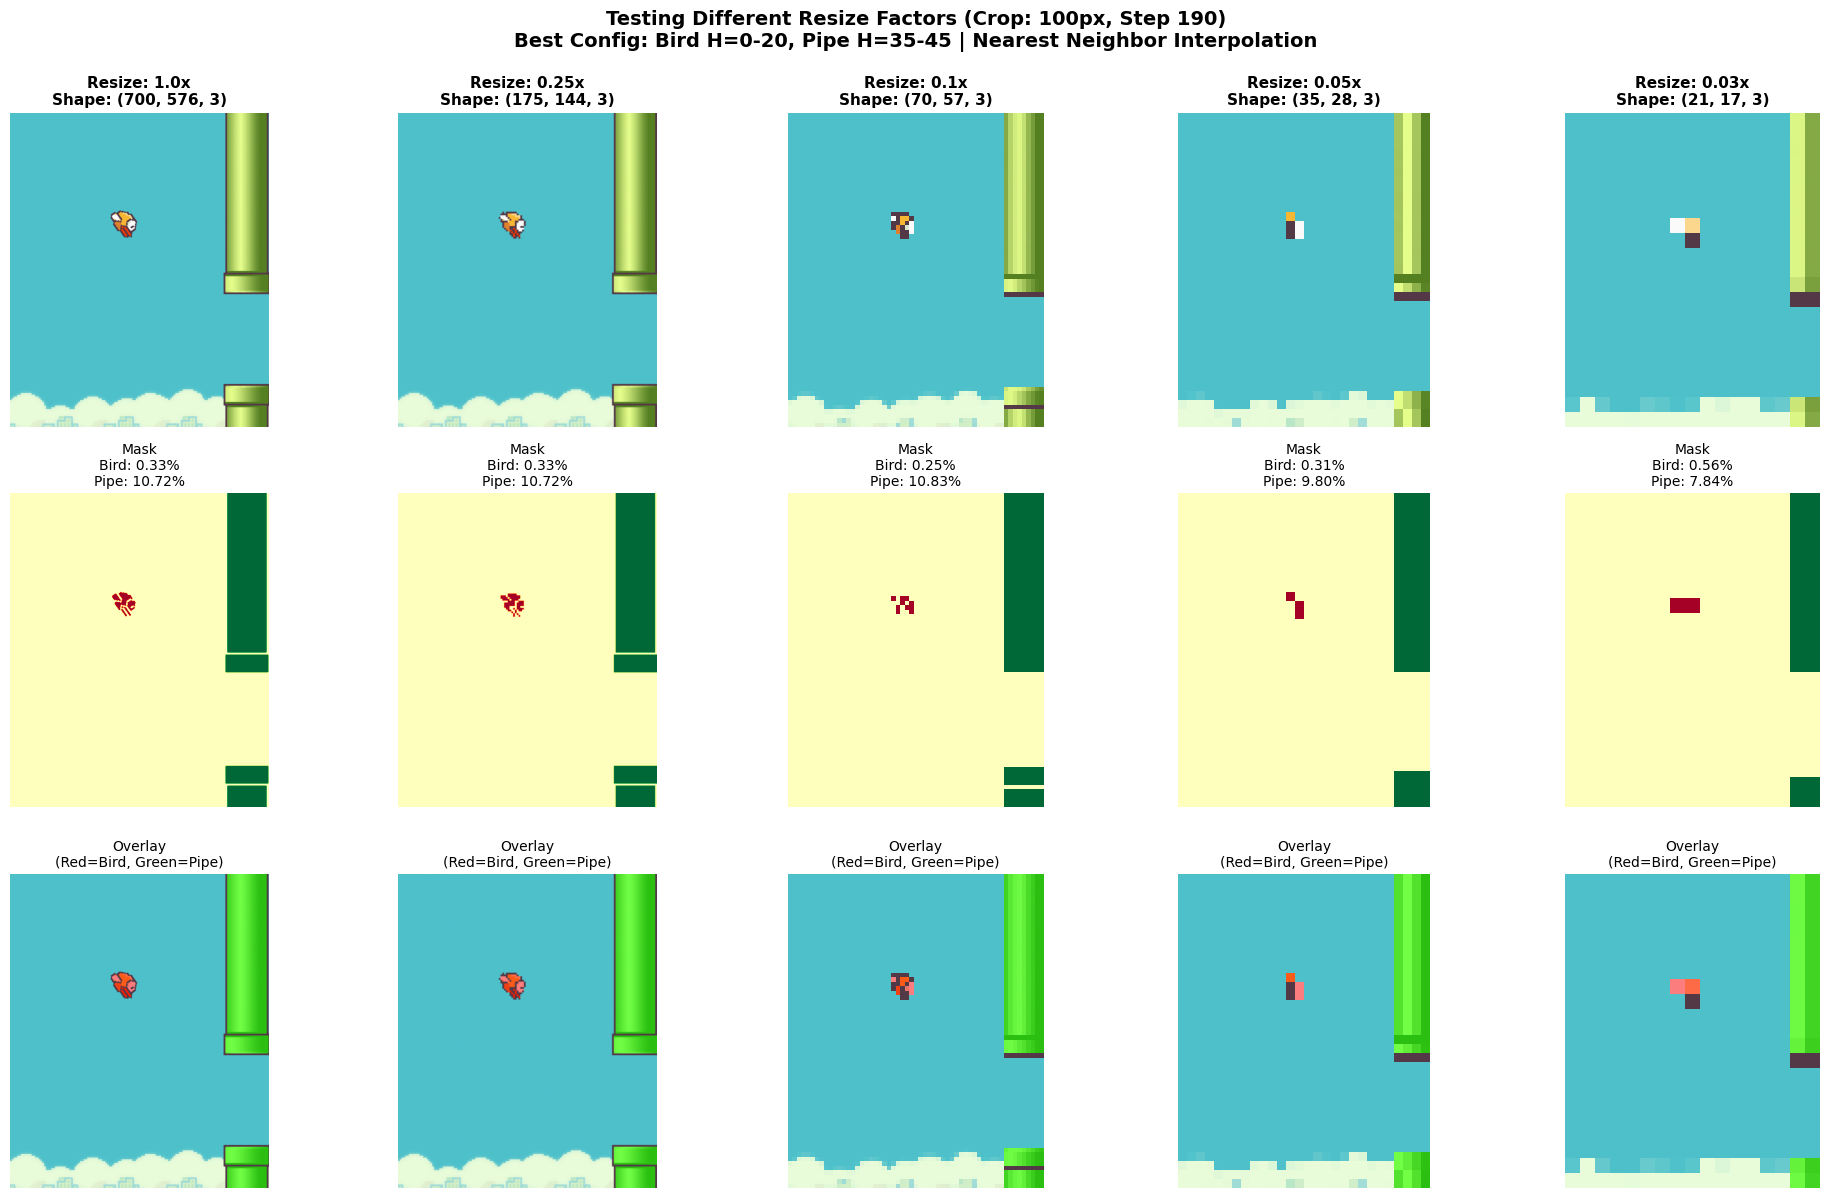


RESIZE FACTOR COMPARISON
Resize Factor   Shape                Total Pixels    Bird %       Pipe %       Bird Count      Pipe Count     
----------------------------------------------------------------------------------------------------
1.00            (700, 576, 3)        403,200         0.33         10.72        1,320           43,220         
0.25            (175, 144, 3)        25,200          0.33         10.72        83              2,702          
0.10            (70, 57, 3)          3,990           0.25         10.83        10              432            
0.05            (35, 28, 3)          980             0.31         9.80         3               96             
0.03            (21, 17, 3)          357             0.56         7.84         2               28             

Adjust RESIZE_FACTORS list above to test different ranges!
Note: Using nearest neighbor interpolation to preserve discrete mask values


In [ ]:
# INTERACTIVE: Test different resize factors
# Adjust this list to test different resize values
RESIZE_FACTORS = [1.0, 0.25, 0.1,0.05, 0.03]  # Test: no resize, 75%, 50%, 25%, 10% of original

CROP_BOTTOM = 100  # Fixed at 100 based on previous testing

# Get the frame at step 190
test_frame = None
for frame in captured_frames:
    if frame['step'] == 190:
        test_frame = frame['rgb']
        break

if test_frame is None:
    test_frame = captured_frames[-1]['rgb']
    print(f"Warning: Step 190 not found, using step {captured_frames[-1]['step']} instead")
else:
    print(f"Testing resize factors on step 190")

# Get cropped image (before resize)
h, w = test_frame.shape[:2]
cropped_rgb = test_frame[:h-CROP_BOTTOM, :]

# Generate masks and resized images for each resize factor
results = []
for resize_factor in RESIZE_FACTORS:
    mask = create_mask(test_frame, crop_bottom=CROP_BOTTOM, resize_factor=resize_factor)
    
    # Create resized RGB for display
    if resize_factor != 1.0:
        new_h = int(cropped_rgb.shape[0] * resize_factor)
        new_w = int(cropped_rgb.shape[1] * resize_factor)
        resized_rgb = cv2.resize(cropped_rgb.astype(np.uint8), (new_w, new_h), 
                                  interpolation=cv2.INTER_NEAREST)
    else:
        resized_rgb = cropped_rgb
    
    bird_count = np.sum(mask == -1)
    pipe_count = np.sum(mask == 1)
    bg_count = np.sum(mask == 0)
    total = mask.size
    
    results.append({
        'resize_factor': resize_factor,
        'mask': mask,
        'resized_rgb': resized_rgb,
        'bird_count': bird_count,
        'pipe_count': pipe_count,
        'bg_count': bg_count,
        'total': total,
        'bird_pct': bird_count / total * 100,
        'pipe_pct': pipe_count / total * 100,
        'shape': resized_rgb.shape
    })

# Visualize all resize factors
num_factors = len(RESIZE_FACTORS)
fig, axes = plt.subplots(3, num_factors, figsize=(4*num_factors, 12))

for idx, result in enumerate(results):
    resize_factor = result['resize_factor']
    mask = result['mask']
    resized_rgb = result['resized_rgb']
    
    # Original (resized)
    axes[0, idx].imshow(resized_rgb)
    axes[0, idx].set_title(f"Resize: {resize_factor}x\nShape: {result['shape']}", 
                           fontsize=11, fontweight='bold')
    axes[0, idx].axis('off')
    
    # Mask
    axes[1, idx].imshow(mask, cmap='RdYlGn', vmin=-1, vmax=1)
    axes[1, idx].set_title(f"Mask\nBird: {result['bird_pct']:.2f}%\nPipe: {result['pipe_pct']:.2f}%", 
                          fontsize=10)
    axes[1, idx].axis('off')
    
    # Overlay
    overlay = resized_rgb.copy().astype(np.float32) / 255.0
    bird_overlay = mask == -1
    pipe_overlay = mask == 1
    overlay[bird_overlay] = overlay[bird_overlay] * 0.5 + np.array([1.0, 0.0, 0.0]) * 0.5
    overlay[pipe_overlay] = overlay[pipe_overlay] * 0.5 + np.array([0.0, 1.0, 0.0]) * 0.5
    axes[2, idx].imshow(overlay)
    axes[2, idx].set_title(f"Overlay\n(Red=Bird, Green=Pipe)", fontsize=10)
    axes[2, idx].axis('off')

plt.suptitle(f"Testing Different Resize Factors (Crop: {CROP_BOTTOM}px, Step 190)\nBest Config: Bird H=0-20, Pipe H=35-45 | Nearest Neighbor Interpolation", 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "=" * 100)
print("RESIZE FACTOR COMPARISON")
print("=" * 100)
print(f"{'Resize Factor':<15} {'Shape':<20} {'Total Pixels':<15} {'Bird %':<12} {'Pipe %':<12} {'Bird Count':<15} {'Pipe Count':<15}")
print("-" * 100)
for result in results:
    print(f"{result['resize_factor']:<15.2f} {str(result['shape']):<20} {result['total']:<15,} "
          f"{result['bird_pct']:<12.2f} {result['pipe_pct']:<12.2f} "
          f"{result['bird_count']:<15,} {result['pipe_count']:<15,}")
print("=" * 100)
print(f"\nAdjust RESIZE_FACTORS list above to test different ranges!")
print("Note: Using nearest neighbor interpolation to preserve discrete mask values")


## Resize Factor 0.03 Across Multiple Frames

Visualize how resize factor 0.03 looks across different frames to see consistency.


Showing 11 frames with resize factor 0.03, stretched to 21x21
Frames at steps: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]


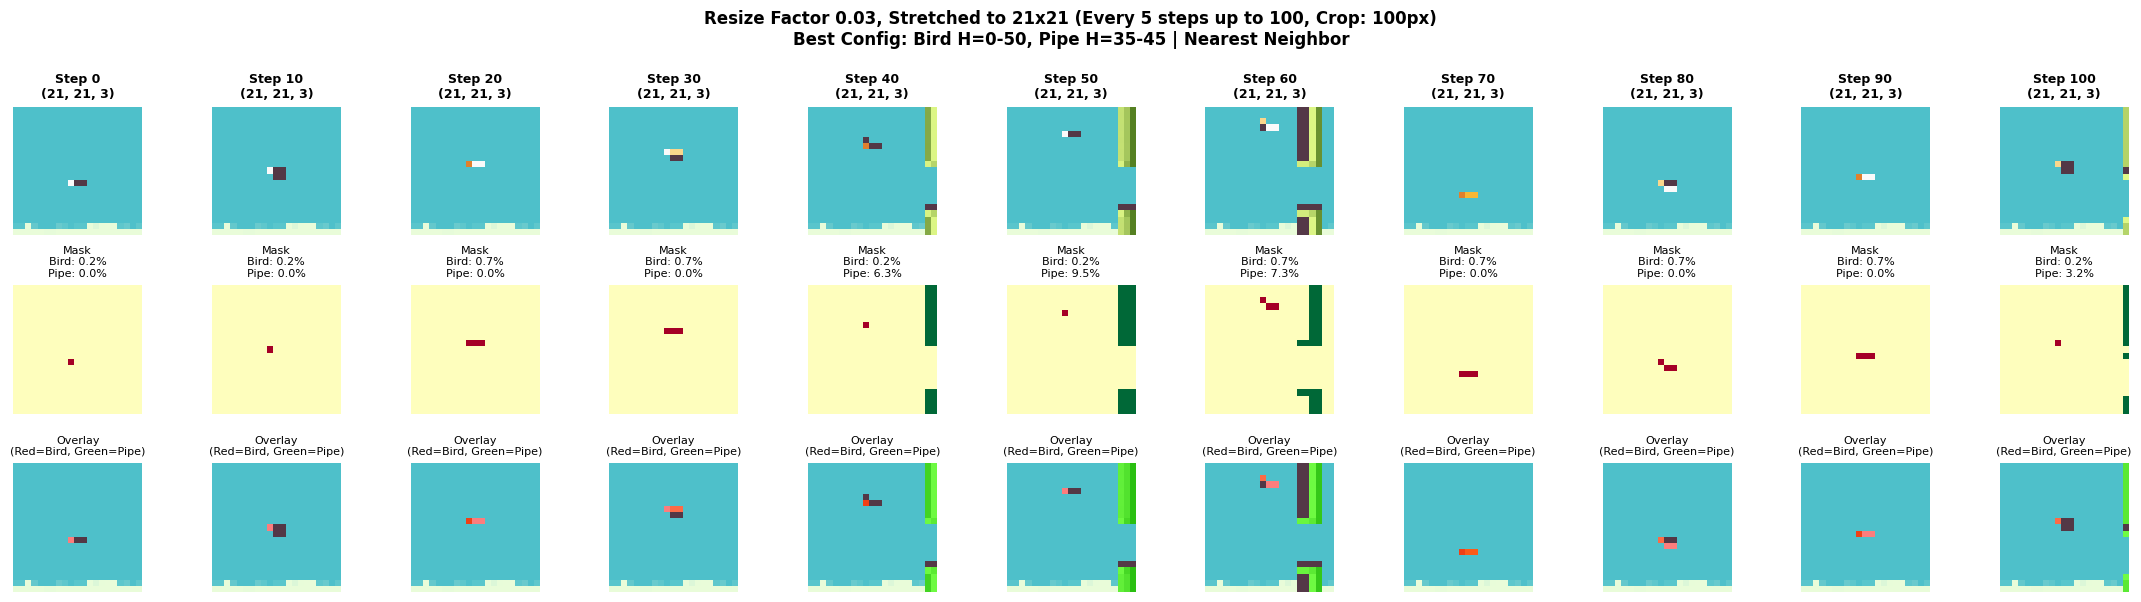


STATISTICS FOR RESIZE FACTOR 0.03 ACROSS FRAMES
Step     Shape                Total Pixels    Bird %       Pipe %       Bird Count      Pipe Count     
----------------------------------------------------------------------------------------------------
0        (21, 21, 3)          441             0.23         0.00         1               0              
10       (21, 21, 3)          441             0.23         0.00         1               0              
20       (21, 21, 3)          441             0.68         0.00         3               0              
30       (21, 21, 3)          441             0.68         0.00         3               0              
40       (21, 21, 3)          441             0.23         6.35         1               28             
50       (21, 21, 3)          441             0.23         9.52         1               42             
60       (21, 21, 3)          441             0.68         7.26         3               32             
70       (21, 21, 

In [ ]:
# Visualize resize factor 0.03 across frames captured every 5 steps, stretched to 21x21
RESIZE_FACTOR = 0.03
CROP_BOTTOM = 100
FINAL_SIZE = 21  # Stretch to 21x21

# Get frames at steps 0, 5, 10, 15, ..., 100 (every 5 steps for 100 steps)
frames_to_show = [f for f in captured_frames if f['step'] % 5 == 0 and f['step'] <= 100]
num_frames = len(frames_to_show)

print(f"Showing {num_frames} frames with resize factor {RESIZE_FACTOR}, stretched to {FINAL_SIZE}x{FINAL_SIZE}")
print(f"Frames at steps: {[f['step'] for f in frames_to_show]}")

# Process each frame
results = []
for frame_data in frames_to_show:
    # Generate mask with resize and stretch
    mask = create_mask(frame_data['rgb'], crop_bottom=CROP_BOTTOM, resize_factor=RESIZE_FACTOR, final_size=FINAL_SIZE)
    
    # Get cropped, resized, and stretched RGB for display
    h, w = frame_data['rgb'].shape[:2]
    cropped_rgb = frame_data['rgb'][:h-CROP_BOTTOM, :]
    new_h = int(cropped_rgb.shape[0] * RESIZE_FACTOR)
    new_w = int(cropped_rgb.shape[1] * RESIZE_FACTOR)
    resized_rgb = cv2.resize(cropped_rgb.astype(np.uint8), (new_w, new_h), 
                              interpolation=cv2.INTER_NEAREST)
    # Stretch to final size
    resized_rgb = cv2.resize(resized_rgb, (FINAL_SIZE, FINAL_SIZE), 
                              interpolation=cv2.INTER_NEAREST)
    
    bird_count = np.sum(mask == -1)
    pipe_count = np.sum(mask == 1)
    total = mask.size
    
    results.append({
        'step': frame_data['step'],
        'resized_rgb': resized_rgb,
        'mask': mask,
        'bird_count': bird_count,
        'pipe_count': pipe_count,
        'total': total,
        'bird_pct': bird_count / total * 100,
        'pipe_pct': pipe_count / total * 100,
        'shape': resized_rgb.shape
    })

# Create visualization - show 3 rows: original (resized), mask, overlay
fig, axes = plt.subplots(3, num_frames, figsize=(2*num_frames, 6))

for idx, result in enumerate(results):
    step = result['step']
    resized_rgb = result['resized_rgb']
    mask = result['mask']
    
    # Row 1: Resized original image
    axes[0, idx].imshow(resized_rgb)
    axes[0, idx].set_title(f"Step {step}\n{result['shape']}", 
                           fontsize=9, fontweight='bold')
    axes[0, idx].axis('off')
    
    # Row 2: Mask
    axes[1, idx].imshow(mask, cmap='RdYlGn', vmin=-1, vmax=1)
    axes[1, idx].set_title(f"Mask\nBird: {result['bird_pct']:.1f}%\nPipe: {result['pipe_pct']:.1f}%", 
                          fontsize=8)
    axes[1, idx].axis('off')
    
    # Row 3: Overlay
    overlay = resized_rgb.copy().astype(np.float32) / 255.0
    bird_overlay = mask == -1
    pipe_overlay = mask == 1
    overlay[bird_overlay] = overlay[bird_overlay] * 0.5 + np.array([1.0, 0.0, 0.0]) * 0.5
    overlay[pipe_overlay] = overlay[pipe_overlay] * 0.5 + np.array([0.0, 1.0, 0.0]) * 0.5
    axes[2, idx].imshow(overlay)
    axes[2, idx].set_title(f"Overlay\n(Red=Bird, Green=Pipe)", fontsize=8)
    axes[2, idx].axis('off')

plt.suptitle(f"Resize Factor {RESIZE_FACTOR}, Stretched to {FINAL_SIZE}x{FINAL_SIZE} (Every 5 steps up to 100, Crop: {CROP_BOTTOM}px)\nBest Config: Bird H=0-50, Pipe H=35-45 | Nearest Neighbor", 
             fontsize=12, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Print statistics across frames
print("\n" + "=" * 100)
print(f"STATISTICS FOR RESIZE FACTOR {RESIZE_FACTOR} ACROSS FRAMES")
print("=" * 100)
print(f"{'Step':<8} {'Shape':<20} {'Total Pixels':<15} {'Bird %':<12} {'Pipe %':<12} {'Bird Count':<15} {'Pipe Count':<15}")
print("-" * 100)
for result in results:
    print(f"{result['step']:<8} {str(result['shape']):<20} {result['total']:<15,} "
          f"{result['bird_pct']:<12.2f} {result['pipe_pct']:<12.2f} "
          f"{result['bird_count']:<15,} {result['pipe_count']:<15,}")

# Calculate averages
avg_bird_pct = np.mean([r['bird_pct'] for r in results])
avg_pipe_pct = np.mean([r['pipe_pct'] for r in results])
avg_bird_count = np.mean([r['bird_count'] for r in results])
avg_pipe_count = np.mean([r['pipe_count'] for r in results])

print("-" * 100)
print(f"{'AVERAGE':<8} {'':<20} {'':<15} {avg_bird_pct:<12.2f} {avg_pipe_pct:<12.2f} "
      f"{int(avg_bird_count):<15,} {int(avg_pipe_count):<15,}")
print("=" * 100)


## View Actual Mask Matrix Values

Display the actual 21x21 mask matrix showing -1, 0, and 1 values.


In [ ]:
# Show the actual mask matrix values (21x21 with -1, 0, 1)
RESIZE_FACTOR = 0.03
CROP_BOTTOM = 100
FINAL_SIZE = 21  # Final mask will be 21x21

# Get a frame to display (step 190 has pipes)
test_frame = None
for frame in captured_frames:
    if frame['step'] == 190:
        test_frame = frame['rgb']
        break

if test_frame is None:
    test_frame = captured_frames[-1]['rgb']
    print(f"Warning: Step 190 not found, using step {captured_frames[-1]['step']} instead")
else:
    print(f"Showing mask matrix for step 190")

# Generate mask
mask = create_mask(test_frame, crop_bottom=CROP_BOTTOM, resize_factor=RESIZE_FACTOR, final_size=FINAL_SIZE)

print(f"\nMask shape: {mask.shape}")
print(f"Mask dtype: {mask.dtype}")
print(f"Unique values: {np.unique(mask)}")
print(f"\n{'='*80}")
print("ACTUAL 21x21 MASK MATRIX VALUES")
print("="*80)
print("Legend: -1 = Bird, 0 = Background, 1 = Pipe\n")

# Display the matrix
np.set_printoptions(threshold=np.inf, linewidth=100, precision=0, suppress=True)
print(mask.astype(int))

# Also show as a formatted grid for better readability
print(f"\n{'='*80}")
print("FORMATTED VIEW (easier to read)")
print("="*80)
print("Legend: B = Bird (-1), . = Background (0), P = Pipe (1)\n")

# Create a character representation
char_mask = np.zeros_like(mask, dtype='U1')
char_mask[mask == -1] = 'B'  # Bird
char_mask[mask == 0] = '.'   # Background
char_mask[mask == 1] = 'P'   # Pipe

# Print row by row for better formatting
for i in range(FINAL_SIZE):
    row_str = ' '.join(char_mask[i, :])
    print(f"Row {i:2d}: {row_str}")

# Statistics
bird_count = np.sum(mask == -1)
pipe_count = np.sum(mask == 1)
bg_count = np.sum(mask == 0)
total = mask.size

print(f"\n{'='*80}")
print("MASK STATISTICS")
print("="*80)
print(f"Shape: {mask.shape} (2D array, NOT 3D RGB image)")
print(f"Total pixels: {total}")
print(f"Bird pixels (-1): {bird_count} ({bird_count/total*100:.1f}%)")
print(f"Background pixels (0): {bg_count} ({bg_count/total*100:.1f}%)")
print(f"Pipe pixels (1): {pipe_count} ({pipe_count/total*100:.1f}%)")
print("="*80)


Showing mask matrix for step 190

Mask shape: (21, 21)
Mask dtype: float32
Unique values: [-1.  0.  1.]

ACTUAL 21x21 MASK MATRIX VALUES
Legend: -1 = Bird, 0 = Background, 1 = Pipe

[[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  1]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  1]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  1]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  1]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  1]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  1]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  1]
 [ 0  0  0  0  0  0  0  0  0 -1 -1 -1  0  0  0  0  0  0  0  1  1]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  1]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  1]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  1]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  1]
 [ 0  0  0  0  0  0  0  0 

## Test Different HSV Thresholds

Test multiple HSV threshold combinations to improve bird (including beak) and pipe detection.


In [ ]:
# Test different HSV threshold combinations
def create_mask_with_params(observation, bird_h_range, bird_s_range, bird_v_range,
                            pipe_h_range, pipe_s_range, pipe_v_range):
    """Create mask with custom HSV ranges, cropping bottom 100 pixels"""
    # Crop bottom 100 pixels to remove ground
    h, w = observation.shape[:2]
    crop_bottom = 100
    cropped_obs = observation[:h-crop_bottom, :]  # Remove bottom 100 rows
    
    hsv = cv2.cvtColor(cropped_obs.astype(np.uint8), cv2.COLOR_RGB2HSV)
    mask = np.zeros((cropped_obs.shape[0], cropped_obs.shape[1]), dtype=np.float32)
    
    bird_lower = np.array([bird_h_range[0], bird_s_range[0], bird_v_range[0]])
    bird_upper = np.array([bird_h_range[1], bird_s_range[1], bird_v_range[1]])
    bird_mask = cv2.inRange(hsv, bird_lower, bird_upper)
    mask[bird_mask > 0] = -1.0
    
    pipe_lower = np.array([pipe_h_range[0], pipe_s_range[0], pipe_v_range[0]])
    pipe_upper = np.array([pipe_h_range[1], pipe_s_range[1], pipe_v_range[1]])
    pipe_mask = cv2.inRange(hsv, pipe_lower, pipe_upper)
    mask[pipe_mask > 0] = 1.0
    
    return mask

# G

## Interactive Threshold Testing

Manually adjust thresholds here to fine-tune detection.


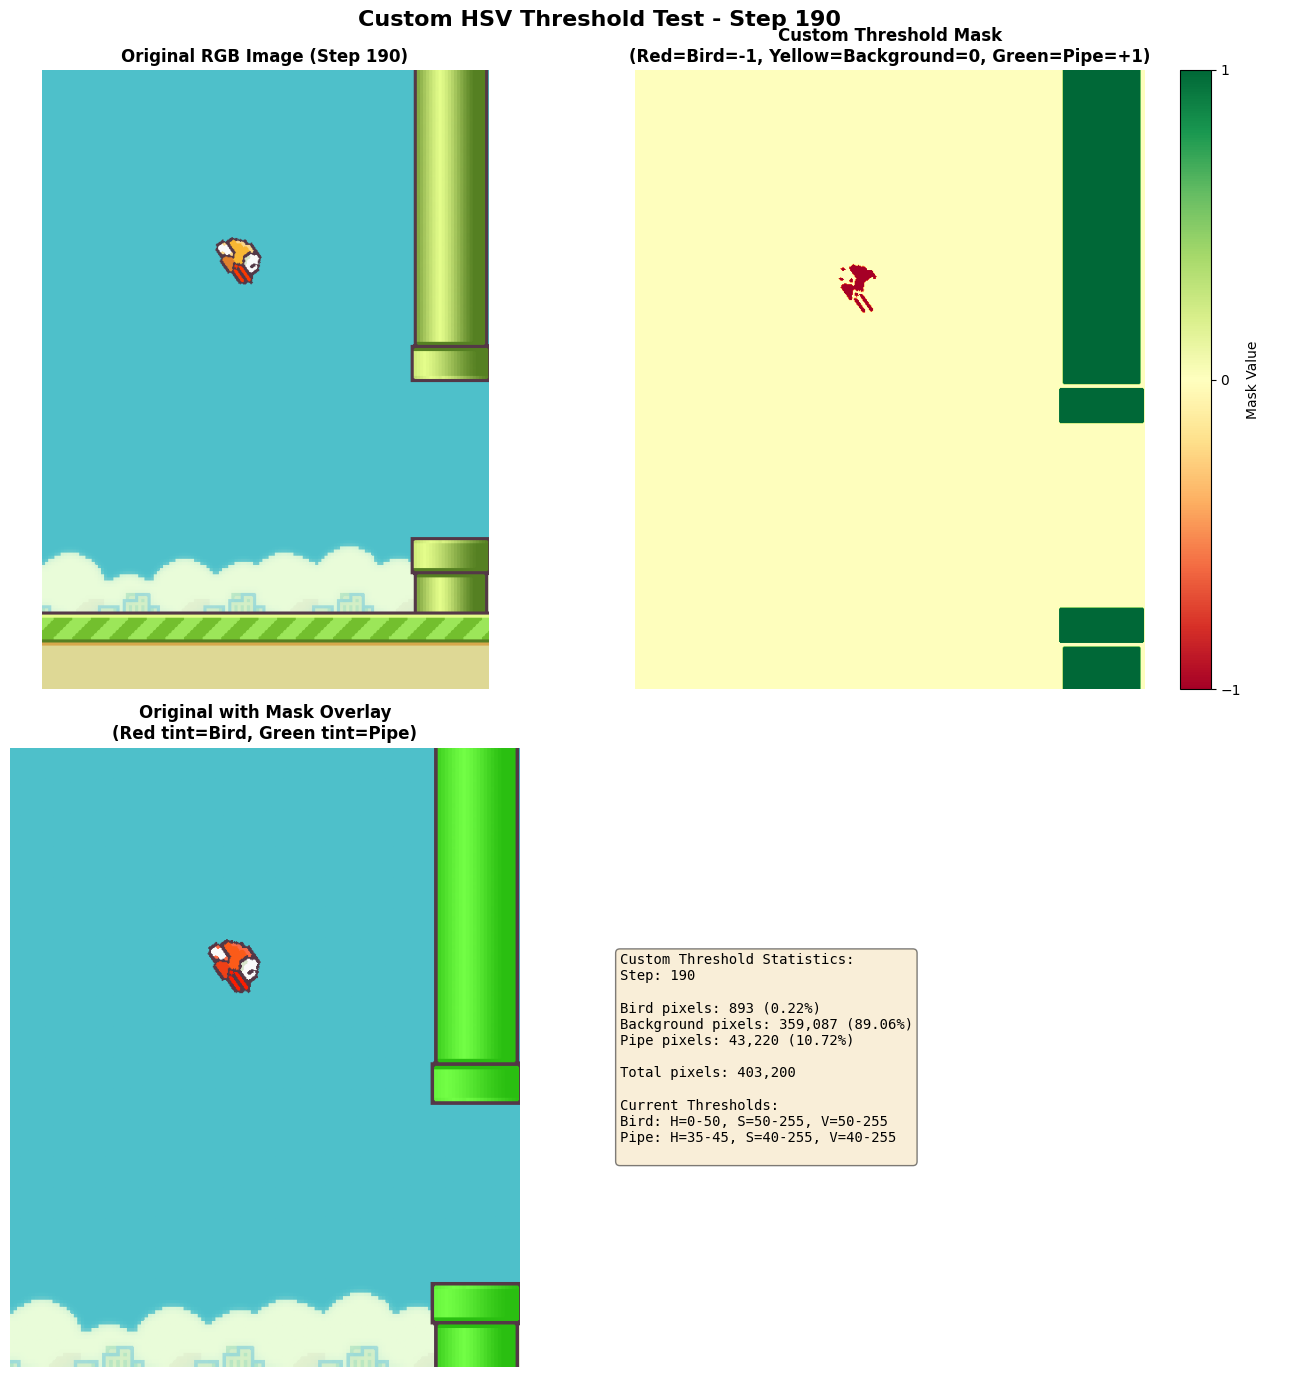

Adjust the threshold variables above and re-run to fine-tune!


: 

In [ ]:
# MANUALLY ADJUST THESE VALUES TO TEST
# After testing above, use the best values here

# Bird HSV ranges (to capture orange/yellow bird AND red beak)
BIRD_H_MIN = 0    # Hue minimum (0-180) - start at 0 to include red
BIRD_H_MAX = 50   # Hue maximum (0-180) - include orange/yellow
BIRD_S_MIN = 50   # Saturation minimum (0-255) - lower to catch more colors
BIRD_S_MAX = 255  # Saturation maximum (0-255)
BIRD_V_MIN = 50   # Value (brightness) minimum (0-255) - lower to catch darker pixels
BIRD_V_MAX = 255  # Value maximum (0-255)

# Pipe HSV ranges (to capture green pipes completely)
PIPE_H_MIN = 35   # Hue minimum (0-180) - start lower to catch all greens
PIPE_H_MAX = 45   # Hue maximum (0-180) - extend higher to catch all green shades
PIPE_S_MIN = 40   # Saturation minimum (0-255)
PIPE_S_MAX = 255  # Saturation maximum (0-255)
PIPE_V_MIN = 40   # Value minimum (0-255) - lower to catch darker greens
PIPE_V_MAX = 255  # Value maximum (0-255)

# Generate mask with custom thresholds
test_frame = None
for frame in captured_frames:
    if frame['step'] == 190:
        test_frame = frame['rgb']
        break

if test_frame is None:
    test_frame = captured_frames[-1]['rgb']

mask_custom = create_mask_with_params(
    test_frame,
    (BIRD_H_MIN, BIRD_H_MAX), (BIRD_S_MIN, BIRD_S_MAX), (BIRD_V_MIN, BIRD_V_MAX),
    (PIPE_H_MIN, PIPE_H_MAX), (PIPE_S_MIN, PIPE_S_MAX), (PIPE_V_MIN, PIPE_V_MAX)
)

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 14))

# Original
axes[0, 0].imshow(test_frame)
axes[0, 0].set_title(f"Original RGB Image (Step 190)", fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# Mask
mask_display = axes[0, 1].imshow(mask_custom, cmap='RdYlGn', vmin=-1, vmax=1)
axes[0, 1].set_title("Custom Threshold Mask\n(Red=Bird=-1, Yellow=Background=0, Green=Pipe=+1)", 
                     fontsize=12, fontweight='bold')
axes[0, 1].axis('off')
plt.colorbar(mask_display, ax=axes[0, 1], ticks=[-1, 0, 1], label='Mask Value')

# Overlay (crop RGB to match mask size)
crop_bottom = 100
h, w = test_frame.shape[:2]
cropped_rgb = test_frame[:h-crop_bottom, :]  # Crop bottom 100 pixels

overlay = cropped_rgb.copy().astype(np.float32) / 255.0
bird_overlay = mask_custom == -1
pipe_overlay = mask_custom == 1
overlay[bird_overlay] = overlay[bird_overlay] * 0.5 + np.array([1.0, 0.0, 0.0]) * 0.5  # Red tint for bird
overlay[pipe_overlay] = overlay[pipe_overlay] * 0.5 + np.array([0.0, 1.0, 0.0]) * 0.5  # Green tint for pipe
axes[1, 0].imshow(overlay)
axes[1, 0].set_title("Original with Mask Overlay\n(Red tint=Bird, Green tint=Pipe)", 
                     fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

# Statistics
bird_count = np.sum(mask_custom == -1)
pipe_count = np.sum(mask_custom == 1)
bg_count = np.sum(mask_custom == 0)
total = mask_custom.size

stats_text = f"""Custom Threshold Statistics:
Step: 190

Bird pixels: {bird_count:,} ({bird_count/total*100:.2f}%)
Background pixels: {bg_count:,} ({bg_count/total*100:.2f}%)
Pipe pixels: {pipe_count:,} ({pipe_count/total*100:.2f}%)

Total pixels: {total:,}

Current Thresholds:
Bird: H={BIRD_H_MIN}-{BIRD_H_MAX}, S={BIRD_S_MIN}-{BIRD_S_MAX}, V={BIRD_V_MIN}-{BIRD_V_MAX}
Pipe: H={PIPE_H_MIN}-{PIPE_H_MAX}, S={PIPE_S_MIN}-{PIPE_S_MAX}, V={PIPE_V_MIN}-{PIPE_V_MAX}
"""
axes[1, 1].text(0.05, 0.5, stats_text, fontsize=10, 
                verticalalignment='center', family='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1, 1].axis('off')

plt.suptitle(f"Custom HSV Threshold Test - Step 190", 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("=" * 80)
print("Adjust the threshold variables above and re-run to fine-tune!")
print("=" * 80)
